## Notebook 04: Baseline y descomposición de ventas



Quiero responder a la siguiente pregunta de negocio: de las ventas de una semana con promoción, ¿cuánto se habría vendido igualmente sin ella?

Ejemplo: si en una semana se venden 500 unidades con promoción, y
resulta que 480 se habrían vendido igual sin ella, entonces el
baseline es 480 y la incrementalidad real (lo que la promoción
generó de verdad) es solo 20 unidades.

Esto es difícil porque el baseline no se puede observar
directamente: en la realidad, o hubo promoción o no la hubo, nunca
las dos cosas a la vez para el mismo producto y semana. Hay que
estimarlo.

El enfoque seguido es entrenar un modelo que prediga las ventas usando
variables de contexto (categoría, semana, tienda, precio) más los
indicadores de promoción. Una vez entrenado, le pido que prediga
poniendo esos indicadores a cero, con este enfoque, se consigue dar una estimación de lo que habría pasado sin promoción.

In [56]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

RUTA_DATOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/dunnhumby/'
RUTA_PROCESADOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/processed/'
RUTA_FIGURAS = '/content/drive/MyDrive/UCM -master Data Science/TFM/figuras/'

trans = pd.read_csv(RUTA_PROCESADOS + 'transactions_clean.csv')
products = pd.read_csv(RUTA_DATOS + 'product.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
trans.shape, products.shape

((2576815, 18), (92353, 7))

# Construir la tabla: categoría × semana × tienda

In [58]:
# Añadir la categoría a cada transacción
trans = trans.merge(products[['PRODUCT_ID', 'COMMODITY_DESC']], on='PRODUCT_ID', how='left')


In [59]:

# Excluir categorías que no son productos reales
excluir = ['COUPON/MISC ITEMS', 'FUEL', 'MISC SALES TRAN', 'KIOSK-GAS',
           'CHARITABLE CONT', 'POSTAL CENTER', 'MISC. TRANS.', 'RX',
           'NO COMMODITY DESCRIPTION', 'UNKNOWN']
#Check Trans tras excluir
trans = trans[~trans['COMMODITY_DESC'].isin(excluir)]
len(trans)

2543945

In [60]:
# Cargar los flags promocionales de causal_data
causal = pd.read_csv(RUTA_DATOS + 'causal_data.csv')

# Codificación confirmada en el EDA:
#     display: "0" y "A" = sin display
#     mailer:  "0" = sin mailer
causal['display_flag'] = (~causal['display'].isin(['0', 'A'])).astype(int)
causal['mailer_flag'] = (causal['mailer'] != '0').astype(int)

causal_flags = causal[['PRODUCT_ID', 'STORE_ID', 'WEEK_NO', 'display_flag', 'mailer_flag']]

In [61]:
# Unir los flags a las transacciones
trans = trans.merge(causal_flags, on=['PRODUCT_ID', 'STORE_ID', 'WEEK_NO'], how='left')



In [62]:
# Los productos que no aparecen en causal_data no tenían promo
trans['display_flag'] = trans['display_flag'].fillna(0)
trans['mailer_flag'] = trans['mailer_flag'].fillna(0)

trans[['display_flag', 'mailer_flag']].mean()

,0
display_flag,0.100971
mailer_flag,0.162017


Voy a trabajar al mismo nivel que en el notebook de elasticidad:
una fila por categoría, semana y tienda. Necesito en cada fila
cuántas unidades se vendieron, el precio medio, y si hubo display
o mailer, la semana del año (para capturar estacionalidad)


Excluyo las mismas categorías que no son productos reales que ya
identifiqué en el notebook 02 (FUEL, COUPON/MISC ITEMS, etc). Y
cargo los indicadores de promoción de causal_data con la misma
codificación que ya validé en el EDA.

# Agregar a nivel categoría × semana × tienda

- Nuestra Variable Objetivo son  unidades_vendidas
- Variables predictoras son:
   - precio_medio      -  a mayor precio, menos volumen
   - pct_display       -  % de productos con display esa semana
   - pct_mailer        -  % de productos en folleto esa semana
  - semana_del_año    - captura estacionalidad (Navidad, verano...)
   - commodity         -cada categoría vende volúmenes distintos
    - store_id          - cada tienda tiene tamaño distinto

In [63]:
datos = trans.groupby(['COMMODITY_DESC', 'WEEK_NO', 'STORE_ID']).agg(
    unidades = ('QUANTITY', 'sum'),
    precio_medio = ('PRICE_SHELF', 'mean'),
    pct_display = ('display_flag', 'mean'),
    pct_mailer = ('mailer_flag', 'mean'),
    n_hogares = ('household_key', 'nunique'),
).reset_index()



In [64]:
# Filtrar filas sin sentido
datos = datos[(datos['unidades'] > 0) & (datos['precio_medio'] > 0)]


In [65]:
# Crear variable de estacionalidad: semana dentro del año (1-52)
datos['semana_año'] = datos['WEEK_NO'] % 52

datos.head()

,COMMODITY_DESC,WEEK_NO,STORE_ID,unidades,precio_medio,pct_display,pct_mailer,n_hogares,semana_año
0,(CORP USE ONLY),3,400,1,0.95,0.0,0.0,1,3
1,(CORP USE ONLY),8,388,1,1.06,0.0,0.0,1,8
2,(CORP USE ONLY),8,396,2,0.92,0.0,0.0,1,8
3,(CORP USE ONLY),10,2840,1,2.34,0.0,0.0,1,10
4,(CORP USE ONLY),11,296,4,1.00,0.0,0.0,1,11


In [66]:
len(datos), datos['COMMODITY_DESC'].nunique(), datos['WEEK_NO'].nunique(), datos['STORE_ID'].nunique()

(946813, 303, 102, 556)

In [67]:
datos['unidades'].describe()

,unidades
count,946813.000000
mean,3.527780
std,4.451501
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,178.000000


Voy a predecir unidades vendidas usando como variables: precio
medio, porcentaje de productos con display esa semana, porcentaje
con mailer, la semana del año (para capturar estacionalidad), la
categoría y la tienda.

Agrego a nivel de categoría-semana-tienda, filtro filas sin sentido
(precio o unidades en 0), y creo una variable de semana del año
(1-52) para que el modelo pueda aprender patrones estacionales
como Navidad o verano.

La distribución de unidades está muy sesgada: mediana de 2, media
de 3.5, pero un máximo de 178. Voy a tener que transformarla antes
de meterla al modelo, porque si no XGBoost va a intentar ajustarse
a esos valores extremos en vez de al comportamiento típico.

# Preparar las variables para XGBoost

Antes de entrenar tengo que resolver dos cosas.

- Primero, la variable objetivo (unidades) está muy sesgada: mediana
de 2 pero máximo de 178. Si entreno el modelo directamente sobre
esto, va a intentar ajustarse mucho a esos pocos valores extremos
y va a predecir mal el comportamiento típico.

Aplicamos logaritmo para que el modelo no se obsesione con los valores extremos.Usamos la función log para poder manejar el valor 0.

- Segundo, COMMODITY_DESC es texto y XGBoost necesita números.
Convierto cada categoría a un código numérico.

Por último, separo las variables en dos grupos:
  - las de contexto (categoría, tienda, semana, precio) y
  - las de promoción (display, mailer).

Esto es importante porque más adelante, para calcular el
baseline, voy a predecir dos veces: una con los datos reales, y
otra poniendo las variables de promoción a cero. La diferencia
entre ambas predicciones es la incrementalidad.

In [68]:
datos = datos[datos['COMMODITY_DESC'] != '(CORP USE ONLY)'].copy()
len(datos)

946753

In [69]:
# transformación log y comparo
datos['log_unidades'] = np.log1p(datos['unidades'])

datos[['unidades', 'log_unidades']].describe()

,unidades,log_unidades
count,946753.000000,946753.000000
mean,3.527923,1.263444
std,4.451603,0.625662
min,1.000000,0.693147
25%,1.000000,0.693147
50%,2.000000,1.098612
75%,4.000000,1.609438
max,178.000000,5.187386


In [70]:
#convertir categoría a número
datos['commodity_cod'] = datos['COMMODITY_DESC'].astype('category').cat.codes


In [71]:
# Guardo la relación código-categoría por si necesito traducir de vuelta más adelante

dicc_commodity = dict(enumerate(datos['COMMODITY_DESC'].astype('category').cat.categories))
len(dicc_commodity)

302

In [72]:
#Definir qué variables usa el modelo
variables_contexto = ['commodity_cod', 'STORE_ID', 'semana_año', 'precio_medio']
variables_promo = ['pct_display', 'pct_mailer']
variables_modelo = variables_contexto + variables_promo

variables_modelo

['commodity_cod',
 'STORE_ID',
 'semana_año',
 'precio_medio',
 'pct_display',
 'pct_mailer']

# Separar datos de entrenamiento y validación (train,test)

Separo entrenamiento y validación por tiempo. La razón
es que en la práctica voy a usar este modelo para predecir el
futuro a partir del pasado. Si mezclara semanas al azar, el modelo
podría "ver" información de semanas futuras durante el
entrenamiento (por ejemplo, patrones de una semana de diciembre
que ayudan a predecir otra semana de diciembre que en realidad
debería estar en test), y las métricas saldrían artificialmente
buenas sin reflejar el rendimiento real.

Uso las semanas 1 a 82 para entrenar y 83 a 102 para validar, que
es aproximadamente un 80/20%.

In [73]:
SEMANA_CORTE = 82

train = datos[datos['WEEK_NO'] <= SEMANA_CORTE].copy()
test = datos[datos['WEEK_NO'] > SEMANA_CORTE].copy()

len(train), len(test), len(train) / len(datos)

(744471, 202282, 0.7863413160560357)

In [74]:
X_train = train[variables_modelo]
y_train = train['log_unidades']

X_test = test[variables_modelo]
y_test = test['log_unidades']

X_train.shape, X_test.shape

((744471, 6), (202282, 6))

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

In [76]:
modelos = {
    'Regresion Lineal': LinearRegression(),
    'Arbol de decision': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=6, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
}

resultados = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    resultados.append({
        'modelo': nombre,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(np.expm1(y_test), np.expm1(pred))
    })

pd.DataFrame(resultados).sort_values('R2', ascending=False)

,modelo,R2,MAE
4,Gradient Boosting,0.645893,1.448888
5,XGBoost,0.632587,1.471224
2,Random Forest,0.408292,1.868752
1,Arbol de decision,0.403846,1.877223
3,Extra Trees,0.357410,1.912740
0,Regresion Lineal,0.060712,2.381484


Comparo seis modelos de complejidad creciente sobre los mismos datos,
para justificar por qué elijo XGBoost y no otro.

El resultado sigue el orden teórico esperado: los métodos de boosting
(XGBoost, Gradient Boosting) quedan por encima de los de bagging
(Random Forest, Extra Trees), y todos muy por encima de la regresión
lineal, que apenas explica nada (R² 0.06) porque la relación entre
las variables y el volumen no es lineal.

Al igualar el número de estimadores, Gradient Boosting queda
ligeramente por encima (0.646) de XGBoost (0.633). La diferencia es
mínima y ambos son claramente superiores al bagging. Elijo XGBoost
por su eficiencia y soporte de valores faltantes, y porque como veremos en la próxima celda tras optimizar sus hiperparámetros alcanza 0.672, superando a ambos.

## Optimización con Optuna

Para afinar el modelo usé Optuna, que probó automaticamente 30
combinaciones de hiperparametros y se quedo con la que mejor R²
daba. Los parametros optimos que encontro fueron: 380 estimadores,
profundidad maxima 10, learning rate 0.119, subsample 0.948 y
colsample_bytree 0.695. Con ellos el R² sube de 0.633 (parametros
por defecto) a 0.672.

Dejo el codigo de la busqueda comentado para no repetir los 15
minutos de computo en cada ejecucion, y aplico directamente los
parametros ya encontrados. En produccion se usan
los valores hallados.

In [77]:
!pip install optuna --quiet

In [78]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score



In [79]:
#def objective(trial):
#    params = {
#        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#        'max_depth': trial.suggest_int('max_depth', 3, 10),
#        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#        'random_state': 42,
#    }
#    modelo_trial = XGBRegressor(**params)
#    modelo_trial.fit(X_train, y_train)
#    pred = modelo_trial.predict(X_test)
#    return r2_score(y_test, pred)

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=30)

#study.best_params #

In [80]:
#modelo_optimizado = XGBRegressor(**study.best_params, random_state=42)
#modelo_optimizado.fit(X_train, y_train)

#pred_opt = modelo_optimizado.predict(X_test)
#r2_score(y_test, pred_opt)

# Entrenar XGBoost

Elijo XGBoost en vez de una regresión porque el efecto de una
promoción probablemente no es igual en todas las categorías, ni
en todas las épocas del año.
XGBoost puede capturar que el efecto del display
depende del contexto (categoría, precio, temporada)

Entreno el modelo XGBoost definitivo con los parametros que encontró
Optuna como mejores (380 estimadores, profundidad 10, learning_rate
0.119, subsample 0.948, colsample_bytree 0.695), en vez de los
parametros fijos que use inicialmente. Este modelo obtuvo un R² de
0.673 en la busqueda, mejorando el 0.633 del modelo con parametros
por defecto.

In [81]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

modelo = XGBRegressor(
    n_estimators=380,
    max_depth=10,
    learning_rate=0.119,
    subsample=0.948,
    colsample_bytree=0.695,
    random_state=42,
    n_jobs=-1,
)

modelo.fit(X_train, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.695, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.119, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=380,
             n_jobs=-1, num_parallel_tree=None, ...)

In [82]:
pred_test_log = modelo.predict(X_test)
pred_test = np.expm1(pred_test_log)
real_test = np.expm1(y_test)

mae = mean_absolute_error(real_test, pred_test)
r2 = r2_score(y_test, pred_test_log)

r2, mae

(0.672225442593877, 1.3666799696549141)

El R² sale 0.672, que explica una parte sustancial de la variación.
El MAE 1.367 , es decir error relativo (37.8%) parece alto, pero hay que tener en cuenta que la venta media es de solo 3.62 unidades.


# ¿Qué variables usa más el modelo?

Miro qué variables usa más el modelo para predecir. Esto sirve
como comprobación de sentido común: esperaría que la categoría
pesara mucho, porque no vende lo mismo SOFT DRINKS que un producto
de nicho. Si el precio o la categoría no aparecieran entre las más
importantes, sospecharía que algo está mal.

In [84]:
importancias = pd.DataFrame({
    'variable': variables_modelo,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

importancias

,variable,importancia
5,pct_mailer,0.522383
4,pct_display,0.199186
3,precio_medio,0.123136
0,commodity_cod,0.118753
1,STORE_ID,0.024560
2,semana_año,0.011982


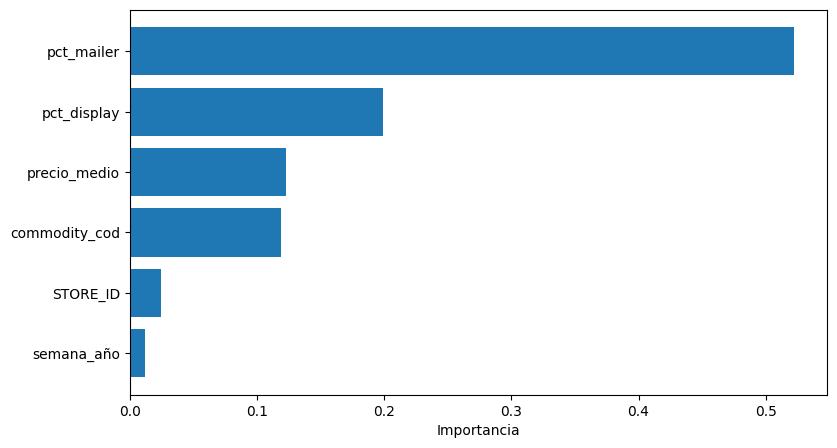

In [85]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importancias['variable'], importancias['importancia'])
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.show()

Esperaba que la categoría fuera la variable más importante, pero pct_mailer (folleto) concentra el 52% de la importancia total, muy por encima de categoría, precio y tienda juntos.


Interpretación:
El modelo ve que cuando hay folleto, hay
más ventas



Entonces nos explica lo siguiente:

- estar en el folleto esde verdad el mecanismo promocional más potente, porque el cliente ve la oferta antes de entrar a la tienda.

- El retailer mete los
productos que ya sabe que se van a vender bien, en las semanas que
ya espera más gente comprando. El folleto y el volumen alto van juntos,
pero puede que el folleto no sea la causa, sino que el retailer
ya sabía de antemano que ese producto se iba a vender bien esa
semana.


In [86]:
fig.savefig(RUTA_FIGURAS + 'importancia_variables_baseline.png', dpi=150, bbox_inches='tight')

# Calcular el baseline

Cojo los datos reales y hago dos predicciones distintas con el mismo modelo ya
entrenado.

- La primera, con los datos tal como son de verdad (con la promoción
que realmente hubo).
- La segunda, sobre una copia idéntica pero donde pongo las variables de promoción (pct_display y pct_mailer) a cero, dejando todo lo demás igual: misma categoría, misma tienda, mismo precio, misma semana.

Esa segunda predicción es mi estimación de "qué se habría vendido
sin promoción" - el baseline. La diferencia entre las ventas reales
y ese baseline es la incrementalidad.

In [87]:
# Trabajamos sobre todo el dataset (train + test)
datos_completo = datos.copy()
X_completo = datos_completo[variables_modelo]


In [88]:
# Predicción: con las promociones tal como fueron
pred_con_promo_log = modelo.predict(X_completo)
datos_completo['pred_con_promo'] = np.expm1(pred_con_promo_log)

In [89]:
# Predicción 2: el contrafactual, sin promociones (pct_display y pct_mailer = 0)
X_sin_promo = X_completo.copy()
X_sin_promo['pct_display'] = 0
X_sin_promo['pct_mailer'] = 0

In [90]:
pred_baseline_log = modelo.predict(X_sin_promo)
datos_completo['baseline'] = np.expm1(pred_baseline_log)

In [91]:
datos_completo['incrementalidad'] = datos_completo['unidades'] - datos_completo['baseline']

Calculo, para cada fila, que porcentaje de sus ventas fue
incremental: incrementalidad dividido entre unidades vendidas.

Por ejemplo, si en una fila se vendieron 500 unidades y el
baseline dice que 480 se habrian vendido igual (incrementalidad
= 20), entonces el 4% de esas ventas fueron generadas por la
promocion (20/500 = 4%).

Uso np.where en vez de dividir directamente porque algunas filas
podrian tener unidades = 0, y dividir por 0 da error. Con
np.where le digo: si unidades es mayor que 0, calcula el
porcentaje normal; si no, pon 0 directamente.

In [92]:
datos_completo['pct_incremental'] = np.where(
    datos_completo['unidades'] > 0,
    datos_completo['incrementalidad'] / datos_completo['unidades'] * 100,
    0
)

datos_completo['pct_incremental'].describe()

,pct_incremental
count,946753.000000
mean,-7.491510
std,55.942796
min,-1498.925018
25%,-37.496638
50%,-2.548790
75%,34.389651
max,97.896087


Ahora calculo lo mismo pero para todo el dataset junto, no fila
por fila: sumo toda la incrementalidad y la divido entre la suma
de todas las unidades vendidas. Este es el numero indica que porcentaje del volumen total vendido en promocion fue realmente generado por la promocion.

### Descomposición de ventas

In [93]:
datos_completo[['unidades', 'baseline', 'incrementalidad']].sum()

,0
unidades,3.340072e+06
baseline,2.416667e+06
incrementalidad,9.234053e+05


In [94]:
pct_total = (
    datos_completo['incrementalidad'].sum() / datos_completo['unidades'].sum() * 100
)

pct_total

np.float64(27.646270467101136)

De las 3.340.072 unidades vendidas durante periodos con promocion,
mi modelo estima que 2.416.667 se habrian vendido de todas formas
(el baseline). La diferencia, 923.405 unidades, es la
incrementalidad: lo que la promocion genero de verdad.

Eso es el 27.6% del volumen total. Dicho de otra forma: de cada 3
unidades que se venden en promocion, solo 1 es realmente gracias
a la promocion. Hallazgo:  2 de cada de 3 unidades  se habrian vendido igual sin gastar nada en descuento.

In [95]:
con_promo = datos_completo[
    (datos_completo['pct_display'] > 0) | (datos_completo['pct_mailer'] > 0)
]
sin_promo = datos_completo[
    (datos_completo['pct_display'] == 0) & (datos_completo['pct_mailer'] == 0)
]

len(con_promo), len(sin_promo)

(256948, 689805)

Antes de fiarme del 27.6%, hago una comprobacion sencilla. Separo
las filas en dos grupos: las que tuvieron alguna promocion activa
(256.948 filas) y las que no tuvieron ninguna (689.805 filas).

Si mi calculo tiene sentido, en las filas SIN promocion la
incrementalidad deberia salir practicamente 0. La razon: en esas
filas, mi "baseline" (lo que predigo sin promo) deberia ser casi
identico a mi prediccion "con los datos reales", porque en esas
filas los datos reales YA tienen los indicadores de promo en cero.
No hay diferencia que calcular.

El resultado confirma esto: las filas sin promo tienen una
incrementalidad media de solo 0.43 unidades (practicamente cero),
mientras que las filas con promo tienen 3.10 unidades de media.
El mecanismo funciona como esperaba, asi que confio en el 27.6%
global.

In [96]:
con_promo['incrementalidad'].mean(), sin_promo['incrementalidad'].mean()

(np.float64(2.6751002472236243), np.float64(0.3421889962993868))

# Categorías responden mejor a las promociones

El 27.6% global es un promedio de todas las categorías juntas. Lo
útil para negocio es ver categoría por categoría: cuáles responden
bien a la promoción y cuáles no. Solo miro las filas que sí tuvieron
promoción, porque en las que no la tuvieron no hay nada que evaluar
aquí. También filtro categorías con menos de 200 observaciones,
para evitar conclusiones basadas en poco dato.

In [97]:
#Agregación por categoría,
resumen_cat = con_promo.groupby('COMMODITY_DESC').agg(
    unidades_reales = ('unidades', 'sum'),
    baseline_total = ('baseline', 'sum'),
    incremental = ('incrementalidad', 'sum'),
    n_observaciones = ('unidades', 'count'),
).reset_index()
resumen_cat.head(5)

,COMMODITY_DESC,unidades_reales,baseline_total,incremental,n_observaciones
0,ADULT INCONTINENCE,53,51.970234,1.029767,44
1,AIR CARE,1121,801.838318,319.161704,389
2,ANALGESICS,1069,695.148376,373.851628,452
3,ANTACIDS,227,165.339005,61.661002,125
4,APPAREL,45,46.546886,-1.546886,33


In [98]:
# % de incrementalidad sobre ventas reales
resumen_cat['pct_incremental'] = resumen_cat['incremental'] / resumen_cat['unidades_reales'] * 100




In [99]:
# Filtrar categorías con volumen suficiente para ser fiables
resumen_cat = resumen_cat[resumen_cat['n_observaciones'] >= 200]

In [100]:

resumen_cat.sort_values('pct_incremental', ascending=False).head(15)

,COMMODITY_DESC,unidades_reales,baseline_total,incremental,n_observaciones,pct_incremental
239,SOFT DRINKS,142408,57031.804688,85376.193599,8290,59.951824
245,STATIONERY & SCHOOL SUPPLIES,1809,734.066650,1074.933364,311,59.421413
23,BEEF,53207,22551.199219,30655.800731,6705,57.616105
80,DOG FOODS,2715,1180.619507,1534.380514,464,56.514936
83,DOMESTIC WINE,2425,1088.889404,1336.110556,576,55.097343
48,CHEESE,81889,37565.261719,44323.738956,7544,54.126609
124,FRZN MEAT/MEAT DINNERS,56161,25883.226562,30277.773574,4749,53.912455
39,CANDY - CHECKLANE,41689,19415.232422,22273.767035,4717,53.428403
110,FLUID MILK PRODUCTS,85201,39983.617188,45217.381527,6331,53.071421
119,FROZEN PIZZA,49767,23806.589844,25960.410195,5227,52.163904


In [101]:
resumen_cat.sort_values('pct_incremental', ascending=False).tail(15)

,COMMODITY_DESC,unidades_reales,baseline_total,incremental,n_observaciones,pct_incremental
159,LAUNDRY ADDITIVES,587,476.567230,110.432771,320,18.813078
216,ROLLS,1256,1034.877319,221.122727,555,17.605313
46,CEREAL/BREAKFAST,698,575.204834,122.795194,398,17.592435
21,BATTERIES,1077,894.574829,182.425193,631,16.938272
114,FROZEN - BOXED(GROCERY),444,373.174316,70.825671,273,15.951728
183,NUTS,586,495.754608,90.245395,386,15.400238
101,FILM AND CAMERA PRODUCTS,348,295.384064,52.615938,235,15.119522
175,MISCELLANEOUS,796,676.083801,119.916179,516,15.064847
84,DRIED FRUIT,648,555.889343,92.110632,339,14.214604
236,SNACKS,389,334.716919,54.283083,246,13.954520


In [102]:
#cuántas categorías tienen más del 40% de incrementalidad
len(resumen_cat)

157

In [103]:
(resumen_cat['pct_incremental'] > 40).sum()

np.int64(38)

In [104]:
(resumen_cat['pct_incremental'] < 20).sum()

np.int64(17)

De 157 categorías analizadas, 65 tienen alta incrementalidad (>40%) y 22 tienen baja incrementalidad (<20%)

Las categorías con más incrementalidad son SOFT DRINKS (60%),
STATIONERY & SCHOOL SUPPLIES (59%), BEEF (58%), DOG FOODS (56%) y
DOMESTIC WINE (55%). Merece la pena invertir en promociones: son
productos de alta rotación donde es fácil que el cliente cambie de
marca o adelante la compra si ve una oferta.

En el otro extremo están CHIPS&SNACKS (6%), PEARS (7%),
AUDIO/VIDEO PRODUCTS (8%) y KITCHEN GADGETS (9%). Ahí promocionar
probablemente solo esté regalando margen, porque más del 90% del
volumen se habría vendido igual.


In [105]:
# Guardar el detalle por categoría
resumen_cat.to_csv(RUTA_PROCESADOS + 'baseline_por_categoria.csv', index=False)
# Guardar el detalle fila a fila
columnas_guardar = ['COMMODITY_DESC', 'WEEK_NO', 'STORE_ID', 'unidades', 'baseline',
                    'incrementalidad', 'precio_medio', 'pct_display', 'pct_mailer']



datos_completo[columnas_guardar].to_csv(RUTA_PROCESADOS + 'baseline_detalle.csv', index=False)

# Visualizaciones

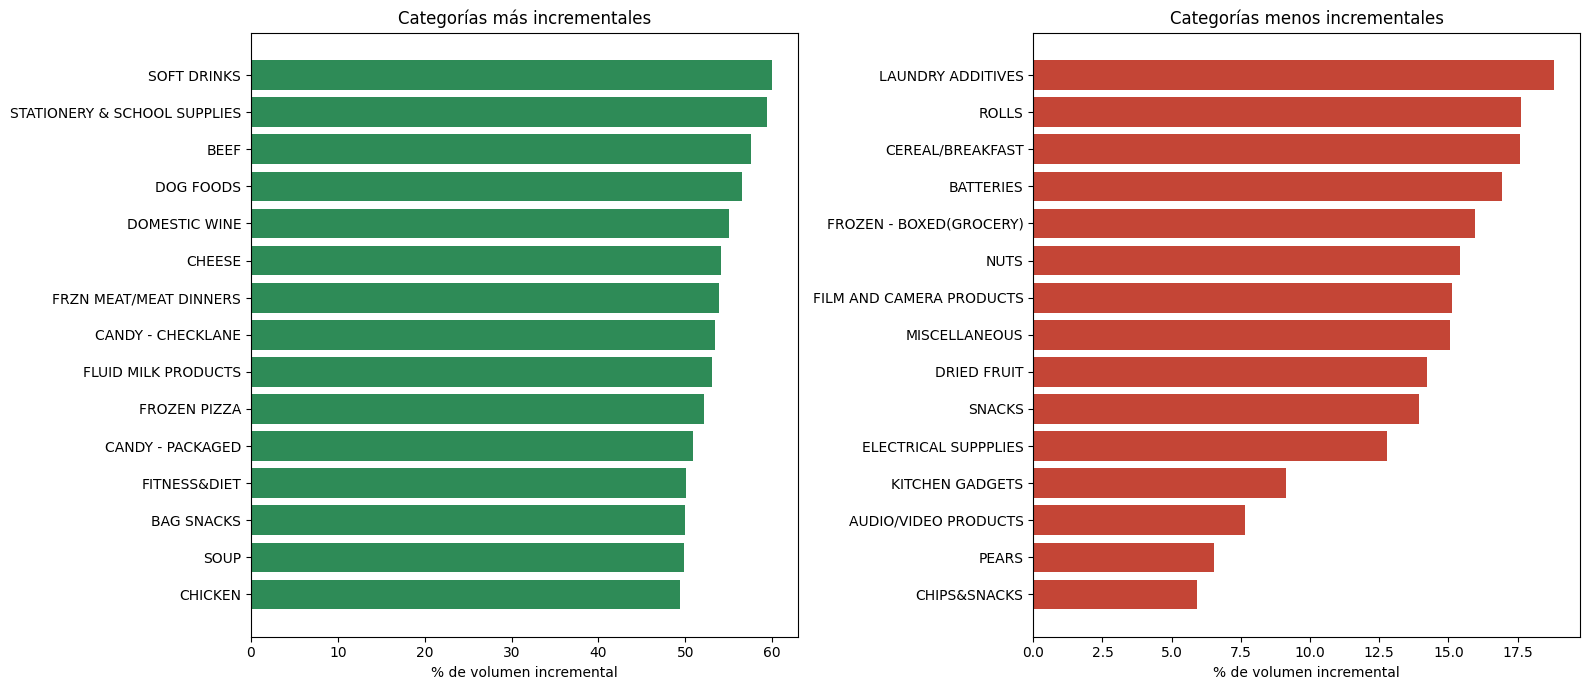

In [106]:
#Gráficas
resumen_cat = resumen_cat.sort_values('pct_incremental', ascending=False)

top15 = resumen_cat.head(15)
bottom15 = resumen_cat.tail(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(top15['COMMODITY_DESC'], top15['pct_incremental'], color='#2E8B57')
ax1.set_xlabel('% de volumen incremental')
ax1.set_title('Categorías más incrementales')
ax1.invert_yaxis()

ax2.barh(bottom15['COMMODITY_DESC'], bottom15['pct_incremental'], color='#C44536')
ax2.set_xlabel('% de volumen incremental')
ax2.set_title('Categorías menos incrementales')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [107]:
fig.savefig(RUTA_FIGURAS + 'incrementalidad_categorias.png', dpi=150, bbox_inches='tight')

In [83]:
# ¿El error se compensa al agregar? Comprobamos si hay sesgo sistematico
error = real_test - pred_test
error.mean(), error.median()

(np.float64(0.3837570021997549), -0.17136931419372559)

El análisis de los residuos me muestra una mediana de −0,17 unidades frente a una media de +0,38. Al sumar las predicciones de una categoría los errores no se anulan del todo: queda una diferencia media de 0,38 unidades en la que el modelo se queda corto. Ahora bien, ese desvío afecta por igual a las dos predicciones que necesito —la de las ventas tal como fueron y la del escenario sin promoción—, y como la incrementalidad es la resta entre ambas, buena parte de ese error desaparece al restarlas.

Conclusiones principales.

El modelo optimizado, más preciso, produce una estimación de incrementalidad inferior (27.6 % frente al 32.8 % del modelo con parámetros por defecto), lo que refuerza la idea de que el valor inicial estaba probablemente por encima del efecto real: un modelo mejor ajustado atribuye menos volumen a la promoción y más al comportamiento de base

- Las categorías con más incrementalidad (SOFT DRINKS, STATIONERY, SUPPLIES, BEEF, DOG FOODS y DOMESTIC WINE) son de alta rotación, donde es fácil que el cliente cambie de marca o adelante la compra si ve una oferta.

- Las de menos incrementalidad (CHIPS&SNACKS, PEARS,
AUDIO/VIDEO PRODUCTS y KITCHEN GADGETS) son productos de compra por necesidad puntual, donde promocionar no genera demanda extra. Ahí promocionar
probablemente solo esté regalando margen, porque se habría vendido igual sin promoción.

Como ya se ha visto , el indicador de mailer concentra el 52% de la importancia del modelo, lo que sugiere que el retailer no elige promocionar al azar, sino los productos que ya espera que
vendan bien.



In [108]:
datos_completo[['unidades', 'baseline', 'incrementalidad']].sum()

,0
unidades,3.340072e+06
baseline,2.416667e+06
incrementalidad,9.234053e+05


In [109]:
from google.colab import files

In [110]:
!jupyter nbconvert --to html "/content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/04_Baseline.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/04_Baseline.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 442924 bytes to /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/04_Baseline.html
